## WW6 – Agtrup 2-min dataset: operational curve under realistic false-alarm constraints

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [ ]:
# --- Upload file in Colab ---
from google.colab import files

uploaded = files.upload()
# Expecting: IOPTQCfFiFoNPo_2min_Agtrup_Aug_2023.csv

In [ ]:
CSV_PATH = "IOPTQCfFiFoNPo_2min_Agtrup_Aug_2023.csv"

cols = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
print("N columns:", len(cols))
cols[:30]

N columns: 11


['date',
 'IN_METAL_Q',
 'T1_O2',
 'METAL_Q',
 'TEMPERATURE',
 'IN_Q',
 'MAX_CF',
 'PROCESSPHASE_INLET',
 'PROCESSPHASE_OUTLET',
 'T1_NH4',
 'T1_PO4']

In [ ]:
# --- Identify likely timestamp columns ---
time_candidates = [c for c in cols if any(k in c.lower() for k in ["time", "date", "timestamp"])]
time_candidates

['date']

In [ ]:
# --- Choose time column ---
TIME_COL = time_candidates[0]  # change if needed
TIME_COL

'date'

In [ ]:
# --- Load data (initial pass) ---
df = pd.read_csv(CSV_PATH, low_memory=False)

print(df.shape)
df.head()

(525600, 11)


,date,IN_METAL_Q,T1_O2,METAL_Q,TEMPERATURE,IN_Q,MAX_CF,PROCESSPHASE_INLET,PROCESSPHASE_OUTLET,T1_NH4,T1_PO4
0,2021-08-01 00:00:00+00:00,0.00,0.027,0.007,16.112,1260.223,82.325,1.0,2.0,0.45,0.09
1,2021-08-01 00:02:00+00:00,33.42,0.000,0.007,16.087,750.600,76.598,2.0,2.0,0.40,0.11
2,2021-08-01 00:04:00+00:00,0.00,0.000,0.007,16.081,985.699,73.796,2.0,2.0,0.40,0.11
3,2021-08-01 00:06:00+00:00,0.00,0.000,0.007,16.062,1410.721,75.523,2.0,1.0,0.20,0.09
4,2021-08-01 00:08:00+00:00,0.00,0.064,0.007,16.093,1129.143,74.262,2.0,1.0,0.20,0.09


In [ ]:
# --- Parse time column ---
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce", utc=True)
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

df[[TIME_COL]].head(), df[[TIME_COL]].tail()

(                       date
 0 2021-08-01 00:00:00+00:00
 1 2021-08-01 00:02:00+00:00
 2 2021-08-01 00:04:00+00:00
 3 2021-08-01 00:06:00+00:00
 4 2021-08-01 00:08:00+00:00,
                             date
 525595 2023-07-31 23:50:00+00:00
 525596 2023-07-31 23:52:00+00:00
 525597 2023-07-31 23:54:00+00:00
 525598 2023-07-31 23:56:00+00:00
 525599 2023-07-31 23:58:00+00:00)

In [ ]:
# --- Keep numeric columns only (besides time) ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", len(num_cols))
num_cols[:40]

Numeric columns: 10


['IN_METAL_Q',
 'T1_O2',
 'METAL_Q',
 'TEMPERATURE',
 'IN_Q',
 'MAX_CF',
 'PROCESSPHASE_INLET',
 'PROCESSPHASE_OUTLET',
 'T1_NH4',
 'T1_PO4']

In [ ]:
# --- Daily aggregation for comparability with main paper ---
df = df.set_index(TIME_COL)

X_raw = df[num_cols].copy()

daily_mean = X_raw.resample("1D").mean()
daily_std  = X_raw.resample("1D").std()
daily_min  = X_raw.resample("1D").min()
daily_max  = X_raw.resample("1D").max()

F_daily = pd.concat(
    [daily_mean.add_suffix("_mean"),
     daily_std.add_suffix("_std"),
     daily_min.add_suffix("_min"),
     daily_max.add_suffix("_max")],
    axis=1
)

print("Daily samples:", F_daily.shape[0])
F_daily.head()

Daily samples: 730


,IN_METAL_Q_mean,T1_O2_mean,METAL_Q_mean,TEMPERATURE_mean,IN_Q_mean,MAX_CF_mean,PROCESSPHASE_INLET_mean,PROCESSPHASE_OUTLET_mean,T1_NH4_mean,T1_PO4_mean,...,IN_METAL_Q_max,T1_O2_max,METAL_Q_max,TEMPERATURE_max,IN_Q_max,MAX_CF_max,PROCESSPHASE_INLET_max,PROCESSPHASE_OUTLET_max,T1_NH4_max,T1_PO4_max
date,,,,,,,,,,,,,,,,,,,,,
2021-08-01 00:00:00+00:00,26.202110,0.387679,0.232600,16.057064,972.867981,51.283601,1.481944,1.527778,0.488736,0.184153,...,248.662,2.582,35.286,16.429,1904.034,88.273,2.0,2.0,2.61,1.14
2021-08-02 00:00:00+00:00,25.084942,0.216507,1.455701,16.285208,647.796794,40.008858,1.633333,1.288889,0.598786,0.354444,...,250.362,2.682,41.790,16.771,1265.702,100.000,2.0,2.0,3.32,1.31
2021-08-03 00:00:00+00:00,44.539528,0.226828,11.002644,16.604399,636.509654,45.093785,1.559722,1.406944,1.171375,0.854514,...,288.484,9.997,76.866,16.948,1203.547,90.002,2.0,2.0,2.89,3.03
2021-08-04 00:00:00+00:00,31.805889,0.097926,4.220665,16.730642,650.541137,57.492940,1.526389,1.459722,1.504292,0.611264,...,255.859,2.750,64.518,17.087,1418.752,100.000,2.0,2.0,4.08,2.19
2021-08-05 00:00:00+00:00,33.293542,0.004488,6.204890,16.848925,699.587936,60.287960,1.526389,1.463889,1.547569,0.765736,...,255.498,0.408,94.372,17.100,1610.814,100.000,2.0,2.0,4.13,3.59


In [ ]:
# --- Find candidate columns for event definition ---
keywords = ["nh4", "no3", "no2", "do", "o2", "po4", "tp", "tn", "cod", "tss", "eff", "out", "turb", "ammon"]
cands = [c for c in num_cols if any(k in c.lower() for k in keywords)]
cands[:80], len(cands)

(['T1_O2', 'PROCESSPHASE_OUTLET', 'T1_NH4', 'T1_PO4'], 4)

In [ ]:
# --- Choose event signal (edit this after inspecting cands) ---
EVENT_SIGNAL = cands[0]  # change after inspection
EVENT_SIGNAL

'T1_O2'

In [ ]:
event_series = daily_max[EVENT_SIGNAL].rename("event_signal_daily_max")

event_series.describe()

,event_signal_daily_max
count,730.000000
mean,3.499071
std,1.639494
min,0.000000
25%,2.796500
50%,3.538500
75%,3.960750
max,10.000000


In [ ]:
N = len(F_daily)
i_train = int(0.60 * N)
i_val   = int(0.80 * N)

F_train = F_daily.iloc[:i_train].copy()
F_val   = F_daily.iloc[i_train:i_val].copy()
F_test  = F_daily.iloc[i_val:].copy()

event_train = event_series.iloc[:i_train]
event_val   = event_series.iloc[i_train:i_val]
event_test  = event_series.iloc[i_val:]

(F_train.shape, F_val.shape, F_test.shape)

((438, 40), (146, 40), (146, 40))

In [ ]:
mu = F_train.mean()
sd = F_train.std().replace(0, 1.0)

def transform(F):
    F2 = F.copy().fillna(mu)
    return (F2 - mu) / sd

F_train_z = transform(F_train)
F_val_z   = transform(F_val)
F_test_z  = transform(F_test)

In [ ]:
def event_run_statistics(event_days_bool):
    e = event_days_bool.astype(bool).values
    n_event_days = int(e.sum())

    durations = []
    cur = 0
    for v in e:
        if v:
            cur += 1
        else:
            if cur > 0:
                durations.append(cur)
                cur = 0
    if cur > 0:
        durations.append(cur)

    n_events = len(durations)
    if n_events > 0:
        return {
            "n_event_days": n_event_days,
            "n_events": n_events,
            "duration_mean": float(np.mean(durations)),
            "duration_median": float(np.median(durations)),
            "duration_max": int(np.max(durations)),
            "durations": durations
        }
    else:
        return {
            "n_event_days": 0,
            "n_events": 0,
            "duration_mean": np.nan,
            "duration_median": np.nan,
            "duration_max": 0,
            "durations": []
        }

PERCENTILE = 95  # start with 95
thr = np.nanpercentile(event_train.dropna().values, PERCENTILE)
event_days = (event_series >= thr)

stats = event_run_statistics(event_days)
thr, stats

(np.float64(6.006149999999994),
 {'n_event_days': 38,
  'n_events': 33,
  'duration_mean': 1.1515151515151516,
  'duration_median': 1.0,
  'duration_max': 4,
  'durations': [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   4,
   1,
   1,
   1,
   3,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1]})

In [ ]:
def make_horizon_labels(event_bool, H=3):
    e = event_bool.astype(int).values
    y = np.zeros_like(e)
    for i in range(len(e)):
        j1 = i + 1
        j2 = min(i + H, len(e)-1)
        if j1 <= j2 and e[j1:j2+1].sum() > 0:
            y[i] = 1
    return pd.Series(y, index=event_bool.index, name=f"y_H{H}")

H = 3
y = make_horizon_labels(event_days, H=H)
y.value_counts()

,count
y_H3,
0,628
1,102


In [ ]:
def make_rolling_splits(n_days, train_frac=0.60, val_frac=0.20, n_splits=4):
    train_len = int(train_frac * n_days)
    val_len   = int(val_frac * n_days)
    test_len  = n_days - train_len - val_len
    step = max(1, test_len // n_splits)

    splits = []
    for s in range(n_splits):
        train_end = train_len + s * step
        val_end   = min(train_end + val_len, n_days - test_len)
        test_end  = min(val_end + test_len, n_days)
        if test_end <= val_end or val_end <= train_end:
            continue
        splits.append((train_end, val_end, test_end))
    return splits

splits = make_rolling_splits(len(F_daily), n_splits=4)
splits

[(438, 584, 730), (474, 584, 730), (510, 584, 730), (546, 584, 730)]

In [ ]:
def false_alarms_per_30d(alert_bool):
    days = len(alert_bool)
    if days == 0:
        return 0.0
    fa = int(alert_bool.sum())
    return fa * (30.0 / days)

def event_hit_rate(event_days_bool, alert_bool):
    events = event_days_bool.astype(bool)
    n_events_days = int(events.sum())
    if n_events_days == 0:
        return np.nan
    hits = int((events & alert_bool).sum())
    return hits / n_events_days

def operational_curve(scores, event_days_bool, grid_fa=np.linspace(0, 25, 51)):
    qs = np.linspace(0.0, 1.0, 200)
    ths = np.quantile(scores.dropna().values, qs)

    points = []
    for th in ths:
        alert = (scores >= th)
        fa30 = false_alarms_per_30d(alert)
        hr = event_hit_rate(event_days_bool, alert)
        points.append((fa30, hr))

    pts = pd.DataFrame(points, columns=["fa30", "hit_rate"]).sort_values("fa30")
    pts = pts.groupby("fa30", as_index=False)["hit_rate"].mean()

    fa_vals = pts["fa30"].values
    hr_vals = pts["hit_rate"].values
    hr_interp = np.interp(grid_fa, fa_vals, hr_vals, left=hr_vals[0], right=hr_vals[-1])
    return grid_fa, hr_interp, pts

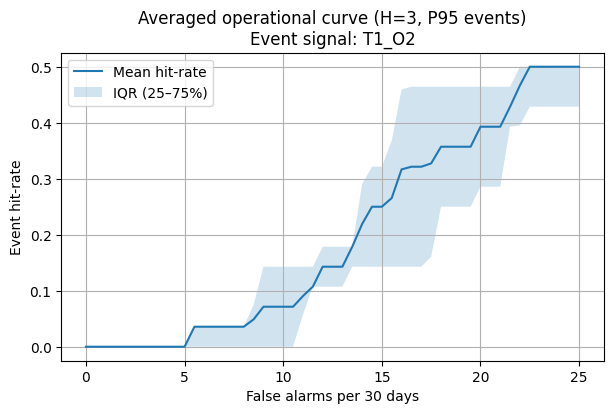

In [ ]:
def fit_lr_and_score(Fz_all, y_all, train_end, val_end, test_end):
    X_tr, y_tr = Fz_all.iloc[:train_end], y_all.iloc[:train_end]
    X_te, y_te = Fz_all.iloc[val_end:test_end], y_all.iloc[val_end:test_end]

    clf = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
    clf.fit(X_tr, y_tr)

    s_te = pd.Series(clf.predict_proba(X_te)[:, 1], index=X_te.index)
    return s_te, y_te

Fz_all = pd.concat([F_train_z, F_val_z, F_test_z], axis=0)

grid_fa = np.linspace(0, 25, 51)
curves = []

for (train_end, val_end, test_end) in splits:
    s_test, y_test = fit_lr_and_score(Fz_all, y, train_end, val_end, test_end)
    ev_test = event_days.iloc[val_end:test_end]

    fa_grid, hr_grid, _ = operational_curve(s_test, ev_test, grid_fa=grid_fa)
    curves.append(hr_grid)

C = np.vstack(curves)
hr_mean = np.nanmean(C, axis=0)
hr_p25  = np.nanpercentile(C, 25, axis=0)
hr_p75  = np.nanpercentile(C, 75, axis=0)

plt.figure(figsize=(7,4))
plt.plot(grid_fa, hr_mean, label="Mean hit-rate")
plt.fill_between(grid_fa, hr_p25, hr_p75, alpha=0.2, label="IQR (25–75%)")
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title(f"Averaged operational curve (H={H}, P{PERCENTILE} events)\nEvent signal: {EVENT_SIGNAL}")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def extract_points(grid_fa, hr_mean, targets=(1,5,10,20)):
    rows = []
    for t in targets:
        i = int(np.argmin(np.abs(grid_fa - t)))
        rows.append((grid_fa[i], float(hr_mean[i])))
    return pd.DataFrame(rows, columns=["fa_per_30d", "hit_rate_mean"])

op_points = extract_points(grid_fa, hr_mean, targets=(1,5,10,20))
op_points

,fa_per_30d,hit_rate_mean
0,1.0,0.000000
1,5.0,0.000000
2,10.0,0.071429
3,20.0,0.392857


'hit-rate_vs_FA30d_Agtrup.png'

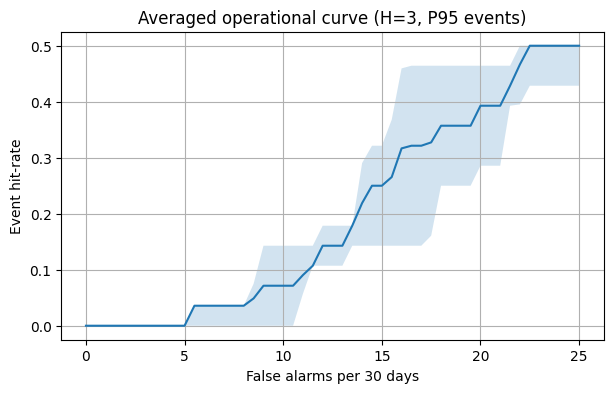

In [ ]:
out_png = "hit-rate_vs_FA30d_Agtrup.png"

plt.figure(figsize=(7,4))
plt.plot(grid_fa, hr_mean)
plt.fill_between(grid_fa, hr_p25, hr_p75, alpha=0.2)
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title(f"Averaged operational curve (H={H}, P{PERCENTILE} events)")
plt.grid(True)
plt.savefig(out_png, dpi=200, bbox_inches="tight")
out_png